# 2 — Feature Engineering

This notebook demonstrates the full feature-engineering pipeline,
showing how raw LMP + weather data is transformed into a model-ready
feature matrix.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath("../src"))

import warnings
warnings.filterwarnings('ignore')

from pjm_spike_forecast.data import build_demo_dataset, load_lmp, load_weather, merge_lmp_weather
from pjm_spike_forecast.config import FeatureConfig
from pjm_spike_forecast.features import (
    add_temporal_features,
    add_lag_features,
    add_rolling_features,
    add_weather_features,
    label_spikes,
    build_feature_matrix,
    get_feature_columns,
)

lmp = load_lmp("../data/raw/nyiso_lmp.csv")
weather = load_weather("../data/raw/weather.csv")
df = merge_lmp_weather(lmp, weather)

# df = build_demo_dataset(n_days=365, seed=42)
print(f"Raw data: {df.shape}")
df.head()

Raw data: (26293, 8)


,lmp,congestion,loss,energy,temperature_c,relative_humidity,wind_speed_kmh,precipitation_mm
datetime_utc,,,,,,,,
2022-01-01 05:00:00+00:00,28.785455,0.000000,2.016364,26.769091,7.9,100,5.1,0.0
2022-01-01 06:00:00+00:00,24.253333,-18.810000,0.402500,42.660833,8.0,100,4.2,0.0
2022-01-01 07:00:00+00:00,26.859167,-16.808333,0.726667,42.940833,7.7,100,6.4,0.0
2022-01-01 08:00:00+00:00,22.192500,-9.110000,0.965833,30.336667,7.7,100,4.7,0.1
2022-01-01 09:00:00+00:00,26.762500,-1.529167,1.781667,26.510000,7.8,100,9.1,0.1


## 2.1 — Temporal Features

Cyclical encoding of hour and month prevents the model from
treating hour 23 and hour 0 as maximally distant.

New columns: ['hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


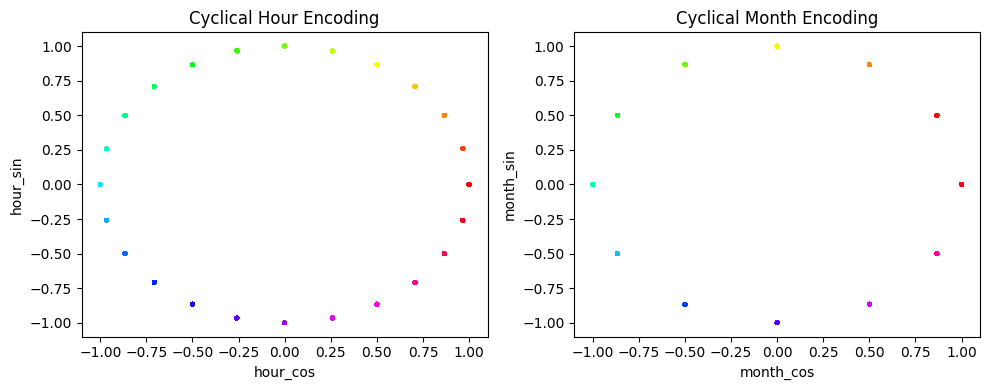

In [3]:
df_temp = add_temporal_features(df)
print("New columns:", [c for c in df_temp.columns if c not in df.columns])

# Show cyclical encoding
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(df_temp["hour_cos"], df_temp["hour_sin"], c=df_temp["hour"],
                cmap="hsv", s=5, alpha=0.3)
axes[0].set_xlabel("hour_cos"); axes[0].set_ylabel("hour_sin")
axes[0].set_title("Cyclical Hour Encoding")

axes[1].scatter(df_temp["month_cos"], df_temp["month_sin"], c=df_temp["month"],
                cmap="hsv", s=5, alpha=0.3)
axes[1].set_xlabel("month_cos"); axes[1].set_ylabel("month_sin")
axes[1].set_title("Cyclical Month Encoding")
plt.tight_layout()
plt.show()

## 2.2 — Lag & Rolling Features

Lag columns: ['lmp_lag_1', 'lmp_lag_24', 'lmp_lag_168']
Rolling columns: ['lmp_rmean_24', 'lmp_rstd_24', 'lmp_rmean_168', 'lmp_rstd_168']


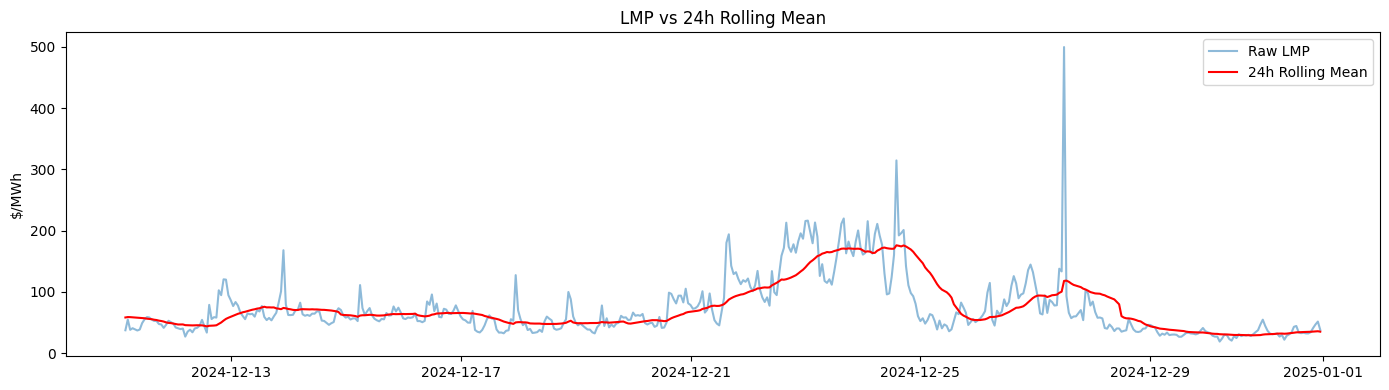

In [4]:
df_lag = add_lag_features(df, "lmp", lags=[1, 24, 168])
print("Lag columns:", [c for c in df_lag.columns if "lag" in c])

df_roll = add_rolling_features(df, "lmp", windows=[24, 168])
print("Rolling columns:", [c for c in df_roll.columns if "rmean" in c or "rstd" in c])

# Plot: raw LMP vs 24h rolling mean
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_roll.index[-500:], df_roll["lmp"].iloc[-500:], alpha=0.5, label="Raw LMP")
ax.plot(df_roll.index[-500:], df_roll["lmp_rmean_24"].iloc[-500:], color="red", label="24h Rolling Mean")
ax.set_ylabel("$/MWh"); ax.set_title("LMP vs 24h Rolling Mean"); ax.legend()
plt.tight_layout()
plt.show()

## 2.3 — Spike Labelling

A spike is an hour where LMP exceeds the 1-week rolling mean + 2σ.

Spike rate: 4.5% of hours
Number of spikes: 1186 out of 26126 hours


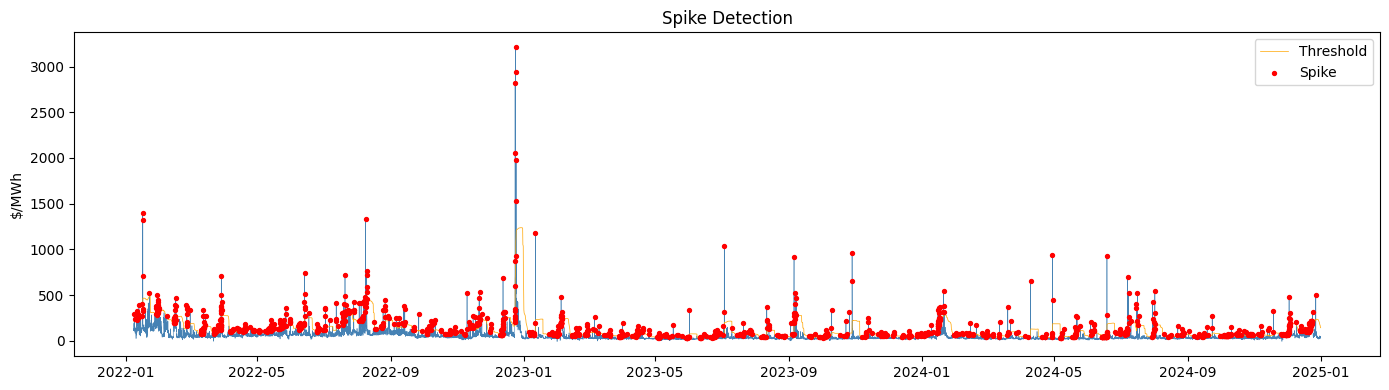

In [5]:
df_spike = label_spikes(df, window=168, n_std=2.0)
valid = df_spike.dropna()
spike_pct = valid["spike"].mean() * 100
print(f"Spike rate: {spike_pct:.1f}% of hours")
print(f"Number of spikes: {int(valid['spike'].sum())} out of {len(valid)} hours")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(valid.index, valid["lmp"], linewidth=0.4, color="steelblue")
ax.plot(valid.index, valid["spike_threshold"], linewidth=0.5, color="orange", label="Threshold")
spikes = valid[valid["spike"] == 1]
ax.scatter(spikes.index, spikes["lmp"], color="red", s=8, zorder=5, label="Spike")
ax.set_ylabel("$/MWh"); ax.set_title("Spike Detection"); ax.legend()
plt.tight_layout()
plt.show()

## 2.4 — Full Feature Matrix

In [6]:
feat_df = build_feature_matrix(df)
feature_cols = get_feature_columns(feat_df)
print(f"Feature matrix: {feat_df.shape}")
print(f"Number of features: {len(feature_cols)}")
print(f"No NaN values: {feat_df.isna().sum().sum() == 0}")
print(f"\nFeature list:")
for i, c in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {c}")

Feature matrix: (26125, 50)
Number of features: 44
No NaN values: True

Feature list:
   1. temperature_c
   2. relative_humidity
   3. wind_speed_kmh
   4. precipitation_mm
   5. hour
   6. day_of_week
   7. month
   8. is_weekend
   9. hour_sin
  10. hour_cos
  11. month_sin
  12. month_cos
  13. lmp_lag_1
  14. lmp_lag_2
  15. lmp_lag_3
  16. lmp_lag_6
  17. lmp_lag_12
  18. lmp_lag_24
  19. lmp_lag_48
  20. lmp_lag_168
  21. temperature_c_lag_1
  22. temperature_c_lag_24
  23. lmp_rmean_6
  24. lmp_rstd_6
  25. lmp_rmin_6
  26. lmp_rmax_6
  27. lmp_rmean_12
  28. lmp_rstd_12
  29. lmp_rmin_12
  30. lmp_rmax_12
  31. lmp_rmean_24
  32. lmp_rstd_24
  33. lmp_rmin_24
  34. lmp_rmax_24
  35. lmp_rmean_48
  36. lmp_rstd_48
  37. lmp_rmin_48
  38. lmp_rmax_48
  39. lmp_rmean_168
  40. lmp_rstd_168
  41. lmp_rmin_168
  42. lmp_rmax_168
  43. temp_squared
  44. temp_x_humidity
